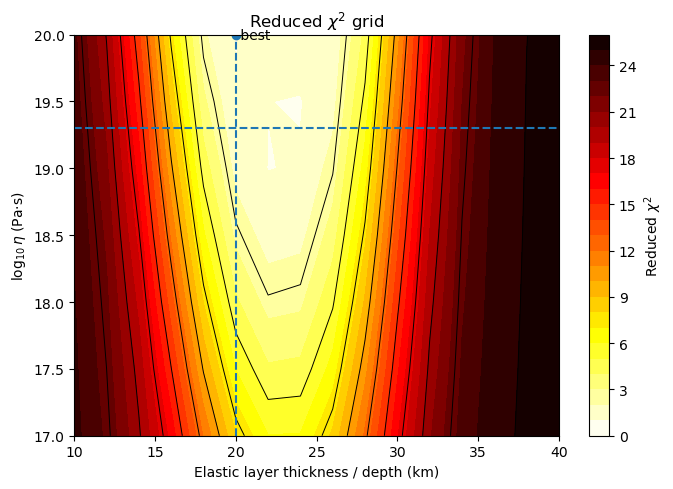

In [13]:
# Chi-square grid-search demo for (depth, viscosity) with simple, safe numerics.
# Replace `run_model()` with your real forward model (RELAX, etc.).
#
# What this cell does:
# 1) Generates synthetic observations from a "true" depth & viscosity.
# 2) Loops over a grid of (depth, log10 viscosity) to compute predictions.
# 3) Computes chi^2 and reduced-chi^2 at each grid point.
# 4) Finds the best fit and plots/saves the chi^2_r map.
#
# You can swap in your own obs/sigma and your own run_model() immediately.

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
# from caas_jupyter_tools import display_dataframe_to_user

# ------------------ User-editable block ------------------
# Grid
depths_km = np.arange(10, 42, 2)         # 10–40 km
log10eta = np.arange(17.0, 20.5, 0.5)    # 17–20 in 0.5 steps (log10 Pa·s)
# If you already have a fixed selection you want to highlight:
dashed_depth = 20
dashed_logeta = 19.3

# Synthetic "truth" for demo — change/remove when using real data
TRUE_DEPTH = 22
TRUE_LOGETA = 19.2

# Observational vector length
N = 120
t = np.linspace(0, 2.0, N)  # arbitrary "time" axis

# Observational noise (heteroscedastic is allowed)
sigma = 0.6 + 0.2*np.cos(2*np.pi*t)              # mm, for example
rng = np.random.default_rng(12345)
# ---------------------------------------------------------


# ------------------ Forward model placeholder ------------------
# Replace this function with your real forward code.
# It MUST return an array of length N (same shape as obs). 
def run_model(depth_km: float, log10_eta: float) -> np.ndarray:
    """
    Toy viscoelastic-ish response: a decaying + slow component.
    The form is irrelevant; you will replace this with RELAX predictions.
    """
    # amplitude and time constants kept in safe ranges to avoid overflow
    A = 8.0 * np.exp(-((depth_km-22.0)**2)/ (2*25.0)) * (1.0 + 0.15*(log10_eta-19.0))
    tau1 = 0.35 + 0.02*(depth_km-20.0) + 0.06*(log10_eta-19.0)  # fast
    tau2 = 0.9  + 0.01*(depth_km-20.0) + 0.05*(log10_eta-19.0)  # slow
    tau1 = np.clip(tau1, 0.15, 1.5)
    tau2 = np.clip(tau2, 0.4,  2.0)
    y = A*(0.7*np.exp(-t/tau1) + 0.3*np.exp(-t/tau2))
    return y
# ---------------------------------------------------------------


# Create synthetic observations from the "true" parameters
obs_clean = run_model(TRUE_DEPTH, TRUE_LOGETA)
obs = obs_clean + rng.normal(0.0, sigma)

# Degrees of freedom: N - M (set M>0 if you fit nuisance params like offsets/ramps)
M = 0
nu = N - M

# Allocate arrays
Nd = depths_km.size
Ne = log10eta.size
chi2 = np.empty((Nd, Ne))
redchi2 = np.empty((Nd, Ne))

# Compute χ² over the grid
for i, H in enumerate(depths_km):
    for j, E in enumerate(log10eta):
        pred = run_model(H, E)
        r = (obs - pred)/sigma
        chi2[i, j] = np.sum(r*r)
        redchi2[i, j] = chi2[i, j]/nu

# Find best fit
best_idx = np.unravel_index(np.argmin(chi2), chi2.shape)
best_depth = depths_km[best_idx[0]]
best_logeta = log10eta[best_idx[1]]
best_vals = {
    "best_depth_km": best_depth,
    "best_log10_eta": best_logeta,
    "chi2_min": float(chi2[best_idx]),
    "redchi2_min": float(redchi2[best_idx]),
    "nu": int(nu),
}

# Save grid to CSV (handy for later plotting/records)
df = pd.DataFrame({
    "depth_km": np.repeat(depths_km, Ne),
    "log10_eta": np.tile(log10eta, Nd),
    "chi2": chi2.reshape(-1),
    "redchi2": redchi2.reshape(-1),
})
# csv_path = "/mnt/data/chi2_grid_depth_viscosity.csv"
# df.to_csv(csv_path, index=False)

# Plot reduced χ² map
D, E = np.meshgrid(depths_km, log10eta, indexing="xy")
fig, ax = plt.subplots(figsize=(7,5))
# Do not specify colors or styles explicitly, per instructions.
cf = ax.contourf(D, E, redchi2.T, levels=24, cmap="hot_r")

cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Reduced $\\chi^2$")

# draw thin χ² contours to show structure
ax.contour(D, E, chi2.T, levels=10, colors="k", linewidths=0.7)

# Mark best fit
ax.plot([best_depth], [best_logeta], "o")
ax.text(best_depth, best_logeta, " best", va="center", ha="left")

# Optional dashed selection guides
ax.axvline(dashed_depth, linestyle="--")
ax.axhline(dashed_logeta, linestyle="--")

ax.set_xlabel("Elastic layer thickness / depth (km)")
ax.set_ylabel("$\\log_{10}\\,\\eta$ (Pa·s)")
ax.set_title("Reduced $\\chi^2$ grid")

fig.tight_layout()
# fig_path = "/mnt/data/chi2_viscosity_vs_depth_demo.png"
# fig.savefig(fig_path, dpi=200)
plt.show()

# Show a small summary to the user
summary = pd.DataFrame([best_vals])
# display_dataframe_to_user("Best-fit summary", summary)

# fig_path, csv_path, best_vals


In [1]:
!hi

/bin/bash: line 1: hi: command not found


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import LinAlgError

# ------------------ USER INPUTS (real data) ------------------
# 1) Provide observations: shape (N,)
obs = ...  # PROIVDE: your stacked vector (e.g., [E1,E2,...,N1,N2,...,U1,U2,...] or time-series)

# 2) Provide uncertainties: either sigma OR full covariance C
sigma = ...      # shape (N,)  (set to None if using C)
C = None         # shape (N,N) (set to None if using sigma)

# 3) Choose whether to fit nuisance terms per grid point
fit_offset = True
fit_scale  = False   # often False for pure physics; True if amplitude is uncertain
fit_linear_trend = False  # set True if you want to absorb a ramp in time, etc.

# 4) Provide the forward model:
USE_PRECOMPUTED = False  # set True if you load predictions from disk

def run_model(depth_km: float, log10_eta: float) -> np.ndarray:
    """
    WRAP YOUR REAL FORWARD MODEL HERE.
    Must return a length-N prediction aligned with `obs`.
    """
    # Example:
    # y = relax_predict(depth_km, log10_eta, ...)
    # return y
    raise NotImplementedError("Implement run_model or set USE_PRECOMPUTED=True.")

# If you precomputed predictions for all grid points:
# pred_grid must be array with shape (Nd, Ne, N): prediction vector per (depth, logeta)
pred_grid = None  # load later if USE_PRECOMPUTED=True

# 5) Your parameter grids
depths_km = np.arange(10, 42, 2)       # 10–40 km
log10eta  = np.arange(17.0, 20.5, 0.5) # 17–20 in 0.5 steps
Nd, Ne = depths_km.size, log10eta.size

# ------------------ Weighting / covariance setup ------------------
N = obs.size
if C is not None:
    # Robust whitening: obs_w = L^{-1} obs with C = L L^T (Cholesky)
    try:
        L = np.linalg.cholesky(C)
        Linv = np.linalg.inv(L)
        def whiten(v): return Linv @ v
        obs_w = whiten(obs)
        use_sigma = False
    except LinAlgError:
        raise ValueError("Covariance not SPD or ill-conditioned; check C.")
elif sigma is not None:
    sigma = np.asarray(sigma)
    if sigma.shape != (N,):
        raise ValueError("sigma must have shape (N,)")
    inv_sigma = 1.0/np.clip(sigma, 1e-12, np.inf)
    def whiten(v): return inv_sigma * v
    obs_w = whiten(obs)
    use_sigma = True
else:
    # Unweighted (not recommended)
    def whiten(v): return v
    obs_w = obs.copy()
    use_sigma = False

# ------------------ Nuisance term projection (optional) ------------------
# Build design matrix X for nuisance terms (columns are basis functions).
X_cols = []
if fit_offset:
    X_cols.append(np.ones(N))
if fit_scale:
    # scale multiplies prediction, so we handle it inside the loop (not here).
    pass
if fit_linear_trend:
    # If your data is time series, provide 't' aligned with obs; else supply another ramp basis.
    t = ...  # PROVIDE time vector aligned with obs (length N)
    X_cols.append(t)

X = None
if len(X_cols) > 0:
    X = np.vstack(X_cols).T  # shape (N, M0) for additive nuisances
    Xw = whiten(X)
    # Precompute GLS normal equations for additive terms:
    XtX_inv = np.linalg.inv(Xw.T @ Xw)
    P_add = Xw @ XtX_inv @ Xw.T  # projector onto nuisance subspace (weighted)

def remove_additive_nuisance(y_pred):
    if X is None:
        return y_pred
    y_pred_w = whiten(y_pred)
    # best-fit additive parameters (GLS): a_hat = (Xw^T Xw)^{-1} Xw^T (obs_w - y_pred_w)
    a_hat = XtX_inv @ (Xw.T @ (obs_w - y_pred_w))
    return y_pred + X @ a_hat  # corrected prediction (includes fitted offset/trend)

def best_scale(obs_w, y_pred_w):
    # Best scalar 's' minimizing ||(obs - s*y_pred)||_W^2: s = (y^T W obs)/(y^T W y)
    num = np.dot(y_pred_w, obs_w)
    den = np.dot(y_pred_w, y_pred_w) + 1e-20
    return num/den

# ------------------ χ² computation over the grid ------------------
chi2 = np.empty((Nd, Ne))
redchi2 = np.empty((Nd, Ne))

for i, H in enumerate(depths_km):
    for j, E in enumerate(log10eta):
        # get prediction
        if USE_PRECOMPUTED:
            y = pred_grid[i, j, :]
        else:
            y = run_model(H, E)

        # handle additive nuisances (offset/trend)
        if X is not None:
            y = remove_additive_nuisance(y)

        # handle scale nuisance
        if fit_scale:
            y_w = whiten(y)
            s = best_scale(obs_w, y_w)
            y = s * y

        # residual and χ² with whitening
        r_w = whiten(obs - y)
        chi2[i, j] = np.dot(r_w, r_w)

# degrees of freedom
M_add = X.shape[1] if X is not None else 0
M_scale = 1 if fit_scale else 0
M = M_add + M_scale
nu = N - M
redchi2 = chi2 / nu

# ------------------ Best fit and simple plotting ------------------
best_idx = np.unravel_index(np.argmin(chi2), chi2.shape)
best_depth = depths_km[best_idx[0]]
best_logeta = log10eta[best_idx[1]]

print({
    "best_depth_km": float(best_depth),
    "best_log10_eta": float(best_logeta),
    "chi2_min": float(chi2[best_idx]),
    "redchi2_min": float(redchi2[best_idx]),
    "nu": int(nu),
    "N": int(N),
    "M": int(M),
})

D, E = np.meshgrid(depths_km, log10eta, indexing="xy")
fig, ax = plt.subplots(figsize=(7,5))
cf = ax.contourf(D, E, redchi2.T, levels=24, cmap="hot_r")
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label("Reduced $\\chi^2$")
ax.contour(D, E, chi2.T, levels=10, colors="k", linewidths=0.7)
ax.plot([best_depth], [best_logeta], "o")
ax.text(best_depth, best_logeta, " best", va="center", ha="left")
ax.set_xlabel("Elastic layer thickness / depth (km)")
ax.set_ylabel("$\\log_{10}\\,\\eta$ (Pa·s)")
ax.set_title("Reduced $\\chi^2$ grid (real data)")
fig.tight_layout()
plt.show()


In [7]:
df

,depth_km,log10_eta,chi2,redchi2
0,10,17.0,2918.973129,24.324776
1,10,17.5,2903.449919,24.195416
2,10,18.0,2887.725652,24.064380
3,10,18.5,2871.816451,23.931804
4,10,19.0,2855.737330,23.797811
...,...,...,...,...
107,40,18.0,3041.039424,25.341995
108,40,18.5,3040.025568,25.333546
109,40,19.0,3038.990405,25.324920
110,40,19.5,3037.935334,25.316128
